# Notebook 03 — State Discrimination

**Project 2 — Superconducting Qubit Readout Signal Processing Pipeline**

---

## Theory

### Readout Fidelity

The **assignment matrix** $M$ encodes classification errors:

$$M = \begin{pmatrix} P(0|0) & P(0|1) \\ P(1|0) & P(1|1) \end{pmatrix}$$

Readout fidelity: $F = 1 - \frac{P(0|1) + P(1|0)}{2}$

### GMM Discriminator

Fits a 2-component Gaussian Mixture Model on combined IQ data; label ambiguity resolved by proximity to known centroids.

### LDA Discriminator

Finds the optimal linear boundary $\mathbf{w}^T \mathbf{x} + b = 0$ that maximises the Fisher ratio. Equivalent to matched filter + threshold under Gaussian noise.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.transmon      import simulate_shots
from src.readout_chain import process_shots_batch
from src.discriminator import (
    GMMDiscriminator, LDADiscriminator,
    assignment_matrix, readout_fidelity,
    compute_roc, fidelity_vs_integration_time)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

data     = simulate_shots(n_shots=1000, rng_seed=42)
t        = data["t"]
shots_0  = data["shots_0"]
shots_1  = data["shots_1"]
template = data["alpha_0"] - data["alpha_1"]

chain_0  = process_shots_batch(shots_0, t, template=template)
chain_1  = process_shots_batch(shots_1, t, template=template)
iq_0     = chain_0["boxcar_iq"]
iq_1     = chain_1["boxcar_iq"]

## 3.1 Fit discriminators

In [2]:
gmm = GMMDiscriminator().fit(iq_0, iq_1)
lda = LDADiscriminator().fit(iq_0, iq_1)

M_gmm = assignment_matrix(gmm, iq_0, iq_1)
M_lda = assignment_matrix(lda, iq_0, iq_1)
F_gmm = readout_fidelity(M_gmm)
F_lda = readout_fidelity(M_lda)

print("=" * 50)
print(f"GMM  fidelity : {F_gmm*100:.3f}%")
print(f"     P(0|1)   : {M_gmm[0,1]*100:.3f}%")
print(f"     P(1|0)   : {M_gmm[1,0]*100:.3f}%")
print("─" * 50)
print(f"LDA  fidelity : {F_lda*100:.3f}%")
print(f"     P(0|1)   : {M_lda[0,1]*100:.3f}%")
print(f"     P(1|0)   : {M_lda[1,0]*100:.3f}%")
print("=" * 50)

GMM  fidelity : 100.000%
     P(0|1)   : 0.000%
     P(1|0)   : 0.000%
──────────────────────────────────────────────────
LDA  fidelity : 100.000%
     P(0|1)   : 0.000%
     P(1|0)   : 0.000%


## 3.2 IQ scatter with decision boundaries

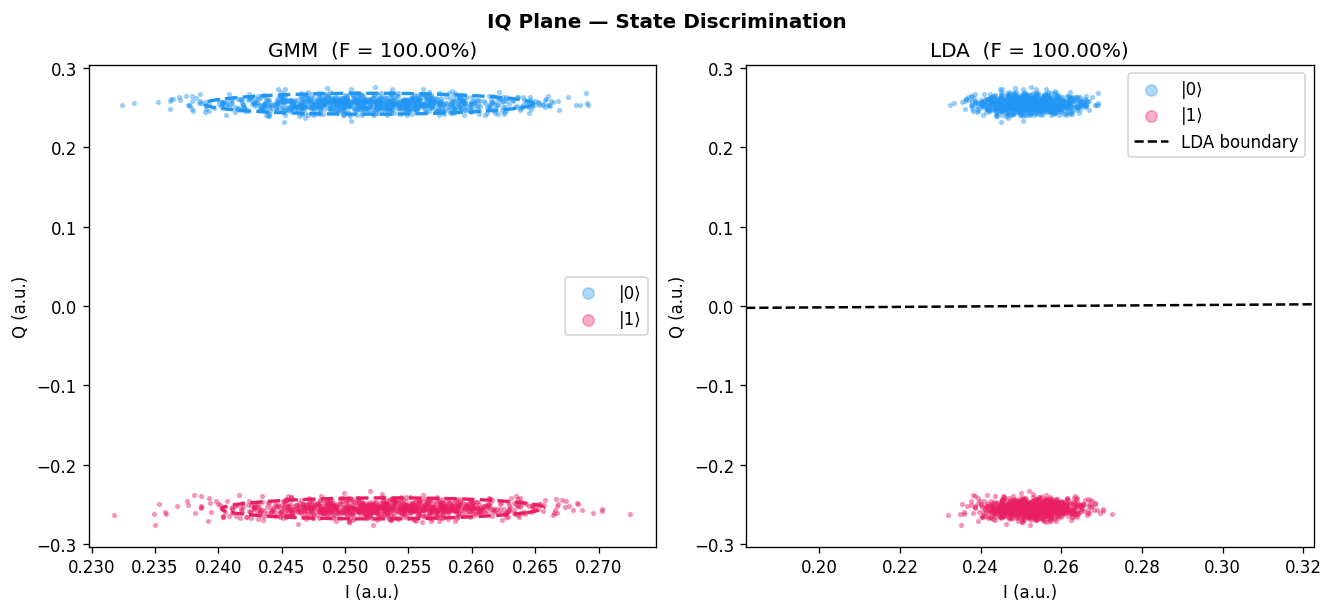

In [3]:
def draw_ellipses(ax, gmm_disc, n_std=2.0):
    for mean, cov, col in zip(gmm_disc.means, gmm_disc.covariances,
                              ["#2196F3", "#E91E63"]):
        eigvals, eigvecs = np.linalg.eigh(cov)
        order   = eigvals.argsort()[::-1]
        eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
        angle   = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
        w, h    = 2*n_std*np.sqrt(eigvals)
        ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle,
                             edgecolor=col, facecolor="none", lw=2,
                             linestyle="--", zorder=5))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
fig.suptitle("IQ Plane — State Discrimination", fontsize=12, fontweight="bold")

for ax, (disc, M, F, title_sfx) in zip(axes, [
    (gmm, M_gmm, F_gmm, "GMM"),
    (lda, M_lda, F_lda, "LDA"),
]):
    ax.scatter(iq_0.real, iq_0.imag, s=5, alpha=0.35,
               color="#2196F3", label="|0⟩", rasterized=True)
    ax.scatter(iq_1.real, iq_1.imag, s=5, alpha=0.35,
               color="#E91E63", label="|1⟩", rasterized=True)
    if title_sfx == "GMM":
        draw_ellipses(ax, gmm)
    else:
        xlim = (min(iq_0.real.min(), iq_1.real.min())-0.05,
                max(iq_0.real.max(), iq_1.real.max())+0.05)
        xs, ys = lda.decision_line_points(xlim)
        ax.plot(xs, ys, "k--", lw=1.5, label="LDA boundary")
        ax.set_xlim(xlim)
    ax.set_xlabel("I (a.u.)"); ax.set_ylabel("Q (a.u.)")
    ax.set_title(f"{title_sfx}  (F = {F*100:.2f}%)")
    ax.legend(markerscale=3)
plt.show()

## 3.3 Confusion matrix

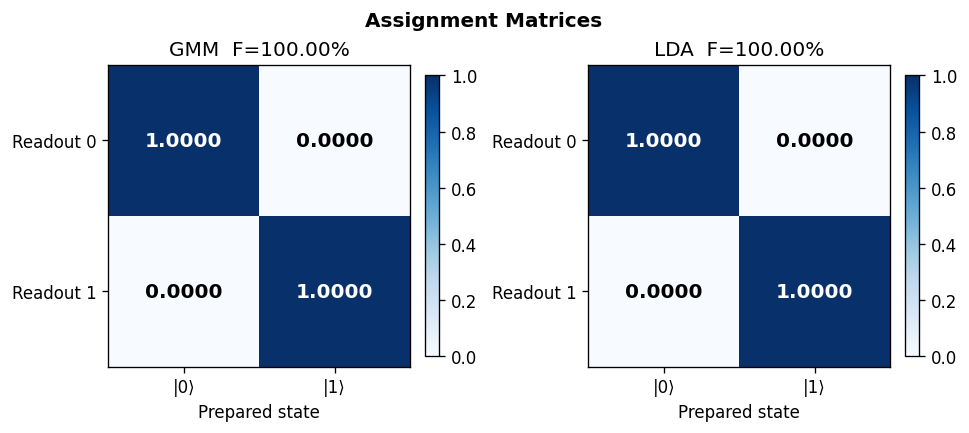

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
fig.suptitle("Assignment Matrices", fontsize=12, fontweight="bold")

for ax, (M, F, label) in zip(axes, [
    (M_gmm, F_gmm, "GMM"),
    (M_lda, F_lda, "LDA"),
]):
    im = ax.imshow(M, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_xticklabels(["|0⟩", "|1⟩"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["Readout 0", "Readout 1"])
    ax.set_xlabel("Prepared state")
    ax.set_title(f"{label}  F={F*100:.2f}%")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{M[i,j]:.4f}", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if M[i,j]>0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 3.4 ROC curve

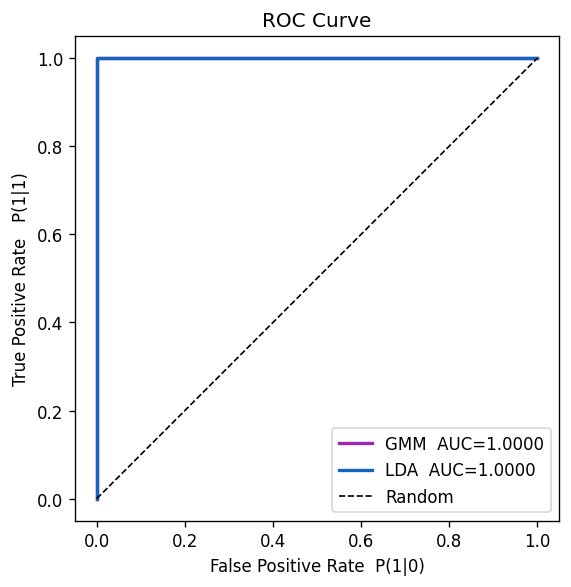

LDA AUC = 1.00000


In [5]:
from sklearn.metrics import auc as sklearn_auc

fpr_g, tpr_g, _, auc_g = compute_roc(gmm, iq_0, iq_1)
fpr_l, tpr_l, _, auc_l = compute_roc(lda, iq_0, iq_1)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr_g, tpr_g, color="#9C27B0", lw=2, label=f"GMM  AUC={auc_g:.4f}")
ax.plot(fpr_l, tpr_l, color="#1565C0", lw=2, label=f"LDA  AUC={auc_l:.4f}")
ax.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate  P(1|0)")
ax.set_ylabel("True Positive Rate   P(1|1)")
ax.set_title("ROC Curve"); ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print(f"LDA AUC = {auc_l:.5f}")

## 3.5 Fidelity vs integration time

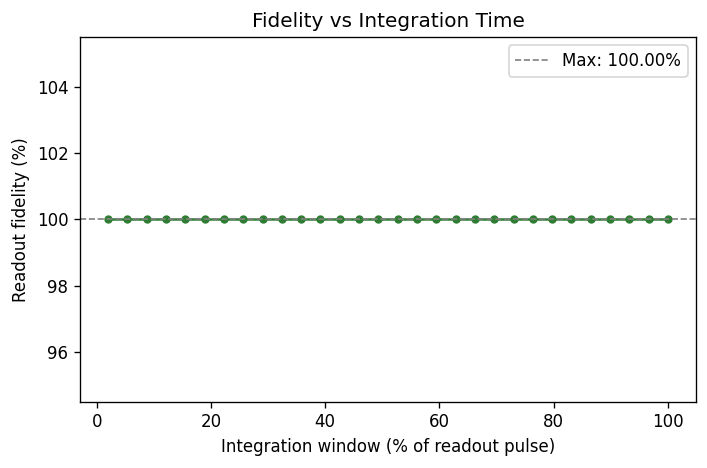

Maximum fidelity: 100.000% at 2% integration


In [6]:
fracs, fidels = fidelity_vs_integration_time(
    chain_0["after_dec"], chain_1["after_dec"], n_fractions=30)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fracs*100, fidels*100, "o-", color="#2E7D32", markersize=4)
ax.set_xlabel("Integration window (% of readout pulse)")
ax.set_ylabel("Readout fidelity (%)")
ax.set_title("Fidelity vs Integration Time")
ax.axhline(fidels.max()*100, color="gray", linestyle="--", linewidth=1,
           label=f"Max: {fidels.max()*100:.2f}%")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Maximum fidelity: {fidels.max()*100:.3f}% at {fracs[np.argmax(fidels)]*100:.0f}% integration")